In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_columns", None)

In [3]:
from plot_utils import topk_barplot, cumsum_plot

In [4]:
sample_size = 25

In [5]:
current_dir = os.getcwd()

data_dir = "tech_challenge-data-us_flights_ml"

In [6]:
flights_csv = "flights.csv"
df_flights = pd.read_csv(os.path.join(current_dir, data_dir, flights_csv))

/tmp/ipykernel_33555/221509293.py:2: DtypeWarning: Columns (0: ORIGIN_AIRPORT, 1: DESTINATION_AIRPORT) have mixed types. Specify dtype option on import or set low_memory=False.
  df_flights = pd.read_csv(os.path.join(current_dir, data_dir, flights_csv))


In [7]:
df_flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              str    
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          str    
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24  CANCELLED

In [8]:
df_flights.sample(n=sample_size)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
4487457,2015,10,7,3,AA,1495,N3CBAA,12889,12892,1230,1227.0,-3.0,29.0,1256.0,78.0,73.0,38.0,236,1334.0,6.0,1348,1340.0,-8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1485921,2015,4,6,1,WN,593,N242WN,ONT,LAS,745,744.0,-1.0,7.0,751.0,55.0,50.0,37.0,197,828.0,6.0,840,834.0,-6.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5765274,2015,12,28,1,WN,3061,N521SW,LBB,DAL,1325,NaN,NaN,NaN,NaN,65.0,NaN,NaN,293,NaN,NaN,1430,NaN,NaN,0,1,B,NaN,NaN,NaN,NaN,NaN
5604987,2015,12,18,5,DL,1714,N803DN,MSP,MCO,700,701.0,1.0,21.0,722.0,196.0,201.0,170.0,1310,1112.0,10.0,1116,1122.0,6.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3108733,2015,7,14,2,B6,1,N657JB,JFK,FLL,946,942.0,-4.0,26.0,1008.0,186.0,191.0,146.0,1069,1234.0,19.0,1252,1253.0,1.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1071521,2015,3,11,3,DL,1964,N987DL,ATL,JAX,1642,1653.0,11.0,14.0,1707.0,73.0,67.0,46.0,270,1753.0,7.0,1755,1800.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4807899,2015,10,27,2,AA,1979,N822AW,11433,11057,1710,1705.0,-5.0,14.0,1719.0,105.0,130.0,90.0,500,1849.0,26.0,1855,1915.0,20.0,0,0,NaN,20.0,0.0,0.0,0.0,0.0
4350233,2015,9,28,1,DL,1926,N3737C,ATL,MCI,1811,1808.0,-3.0,11.0,1819.0,126.0,113.0,97.0,692,1856.0,5.0,1917,1901.0,-16.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5473295,2015,12,9,3,AS,677,N590AS,DEN,SEA,1555,1559.0,4.0,12.0,1611.0,175.0,196.0,178.0,1024,1809.0,6.0,1750,1815.0,25.0,0,0,NaN,25.0,0.0,0.0,0.0,0.0
3730350,2015,8,20,4,UA,1752,N17752,CLE,ORD,743,744.0,1.0,25.0,809.0,89.0,87.0,55.0,315,804.0,7.0,812,811.0,-1.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df_flights["YEAR-MONTH"] = df_flights["YEAR"].astype(str) + df_flights["MONTH"].astype(str).str.zfill(2)
df_flights["YEAR-MONTH"].value_counts(normalize=True)

YEAR-MONTH
201507    0.089485
201508    0.087735
201503    0.086665
201506    0.086594
201505    0.085408
201510    0.083547
201504    0.083372
201512    0.082355
201501    0.080763
201511    0.080420
201509    0.079900
201502    0.073756
Name: proportion, dtype: float64

<Axes: xlabel='YEAR-MONTH'>

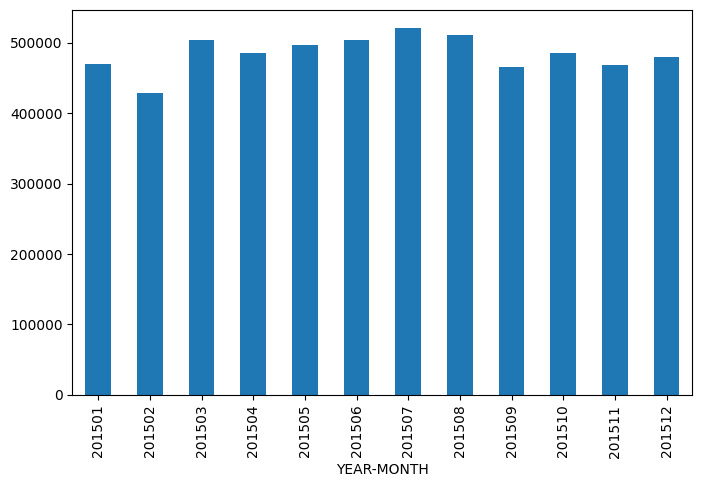

In [10]:
df_flights["YEAR-MONTH"].value_counts().sort_index().plot(kind="bar", figsize=(8, 5))

In [11]:
df_flights["DAY"].value_counts(normalize=True)

DAY
2     0.033680
16    0.033665
20    0.033632
13    0.033526
9     0.033377
8     0.033332
23    0.033263
19    0.033216
15    0.033158
22    0.033120
27    0.032981
28    0.032892
18    0.032891
17    0.032878
6     0.032863
4     0.032805
12    0.032801
11    0.032781
3     0.032652
5     0.032611
1     0.032561
21    0.032550
10    0.032529
14    0.032413
7     0.032238
26    0.032202
25    0.032190
24    0.031795
29    0.030837
30    0.030722
31    0.017840
Name: proportion, dtype: float64

<Axes: xlabel='DAY'>

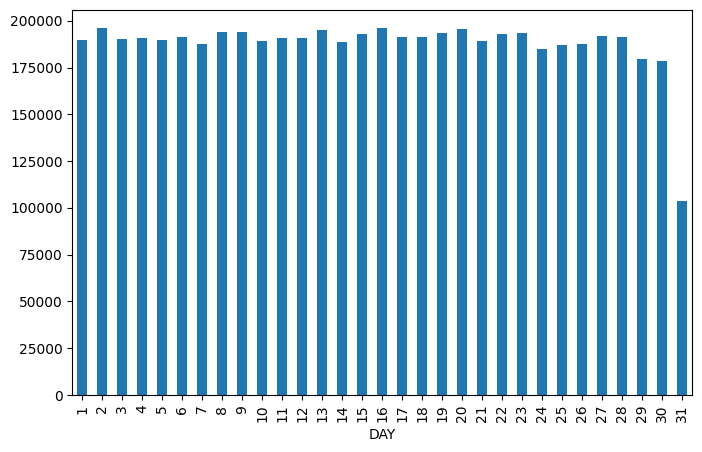

In [12]:
df_flights["DAY"].value_counts().sort_index().plot(kind="bar", figsize=(8, 5))

In [13]:
wd_mapping = {
    1: "MON",
    2: "TUE",
    3: "WED",
    4: "THU",
    5: "FRI",
    6: "SAT",
    7: "SUN",
}

df_flights["DAY_OF_WEEK_ABBR"] = pd.Categorical(
    df_flights["DAY_OF_WEEK"],
    categories=wd_mapping.keys(),
    ordered=True
).rename_categories(wd_mapping)
df_flights["DAY_OF_WEEK_ABBR"].value_counts(normalize=True)

DAY_OF_WEEK_ABBR
THU    0.149941
MON    0.148742
FRI    0.148169
WED    0.147085
TUE    0.145143
SUN    0.140532
SAT    0.120388
Name: proportion, dtype: float64

<Axes: xlabel='DAY_OF_WEEK_ABBR'>

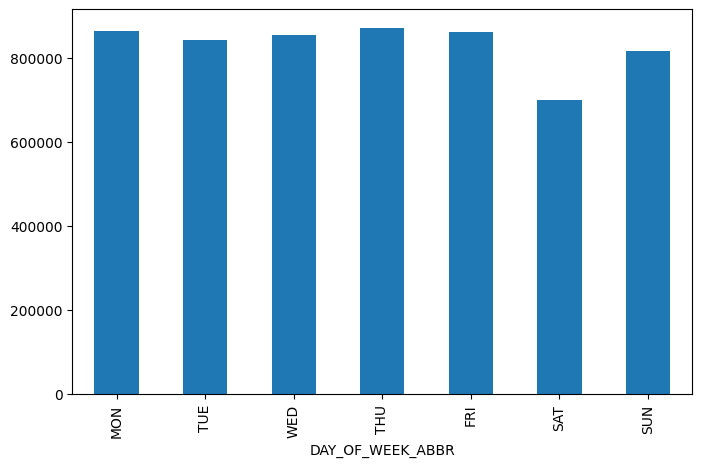

In [14]:
df_flights["DAY_OF_WEEK_ABBR"].value_counts().sort_index().plot(kind="bar", figsize=(8, 5))

In [15]:
df_flights["HOUR"] = df_flights["SCHEDULED_DEPARTURE"] // 100
df_flights["MINUTE"] = df_flights["SCHEDULED_DEPARTURE"] % 100
df_flights["HOUR"].value_counts(normalize=True)

HOUR
6     0.069932
7     0.067699
17    0.067083
8     0.065477
10    0.063866
15    0.063199
13    0.062468
11    0.061536
12    0.061111
9     0.060388
18    0.057463
16    0.057424
19    0.056940
14    0.056661
20    0.044583
21    0.032216
5     0.020287
22    0.020201
23    0.007591
0     0.002520
1     0.000887
2     0.000243
3     0.000134
4     0.000091
Name: proportion, dtype: float64

<Axes: xlabel='HOUR'>

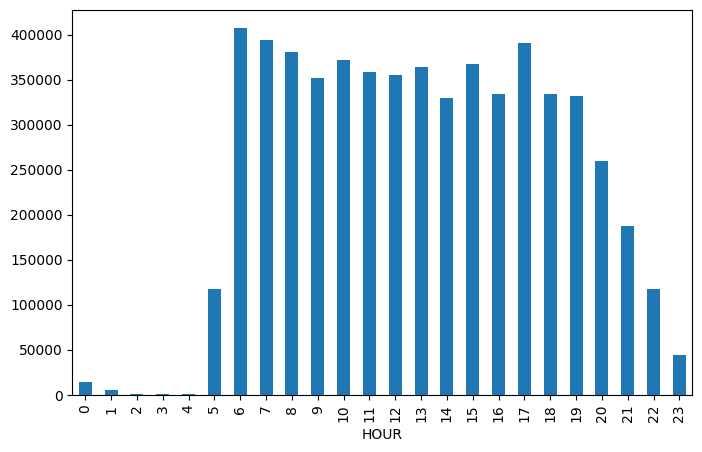

In [16]:
df_flights["HOUR"].value_counts().sort_index().plot(kind="bar", figsize=(8, 5))

In [17]:
df_flights["ORIGIN_AIRPORT"].value_counts(normalize=True)

ORIGIN_AIRPORT
ATL      5.960325e-02
ORD      4.912874e-02
DFW      4.116648e-02
DEN      3.369176e-02
LAX      3.345426e-02
             ...     
14222    1.718485e-07
14025    1.718485e-07
13502    1.718485e-07
15497    1.718485e-07
12265    1.718485e-07
Name: proportion, Length: 930, dtype: float64

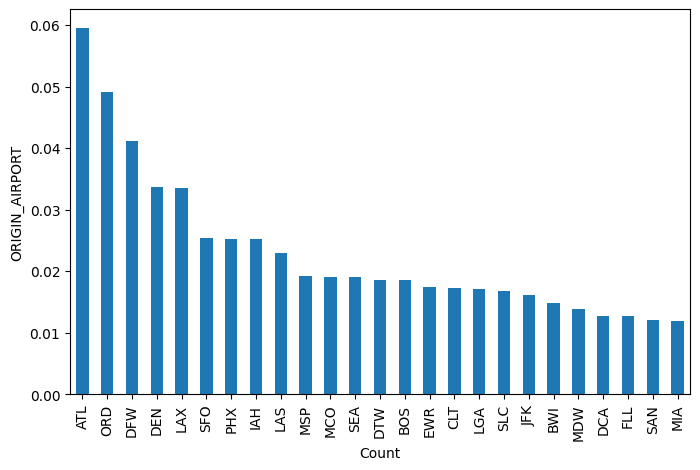

In [18]:
_ = topk_barplot(df_flights["ORIGIN_AIRPORT"], normalize=True, k=25, group_others=False)
plt.show()

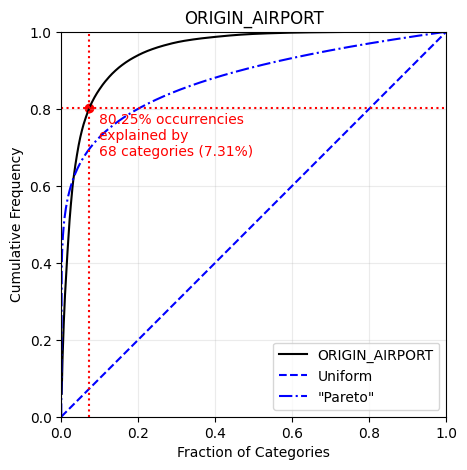

In [19]:
_ = cumsum_plot(df_flights["ORIGIN_AIRPORT"], annotate=True, threshold=0.8)
plt.show()

In [20]:
df_flights["DESTINATION_AIRPORT"].value_counts(normalize=True)

DESTINATION_AIRPORT
ATL      5.961493e-02
ORD      4.913252e-02
DFW      4.117181e-02
DEN      3.368402e-02
LAX      3.345822e-02
             ...     
13459    1.718485e-07
14025    1.718485e-07
15497    1.718485e-07
12265    1.718485e-07
10666    1.718485e-07
Name: proportion, Length: 930, dtype: float64

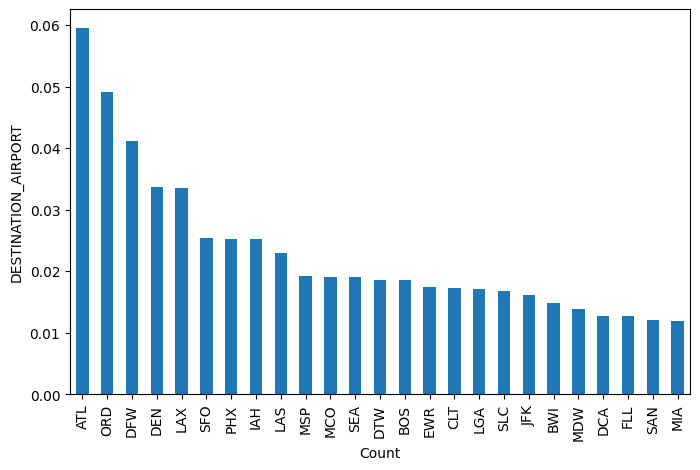

In [21]:
_ = topk_barplot(df_flights["DESTINATION_AIRPORT"], normalize=True, k=25, group_others=False)
plt.show()

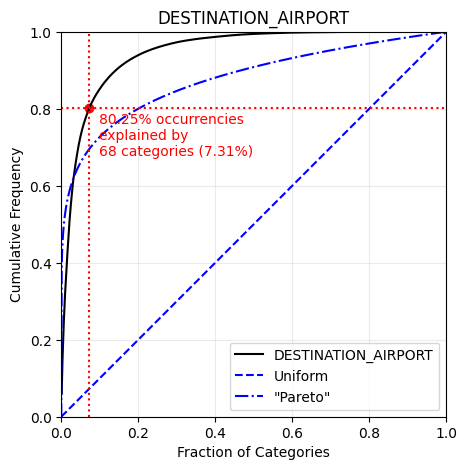

In [22]:
_ = cumsum_plot(df_flights["DESTINATION_AIRPORT"], annotate=True, threshold=0.8)
plt.show()

In [23]:
df_flights["ROUTE"] = df_flights["ORIGIN_AIRPORT"].astype(str) + "-" + df_flights["DESTINATION_AIRPORT"].astype(str)
df_flights["ROUTE"].value_counts(normalize=True)

ROUTE
SFO-LAX    2.361886e-03
LAX-SFO    2.312565e-03
JFK-LAX    2.064932e-03
LAX-JFK    2.064760e-03
LAS-LAX    1.669508e-03
               ...     
GSP-MIA    1.718485e-07
MIA-OKC    1.718485e-07
LRD-HRL    1.718485e-07
OKC-MIA    1.718485e-07
CID-LAX    1.718485e-07
Name: proportion, Length: 8609, dtype: float64

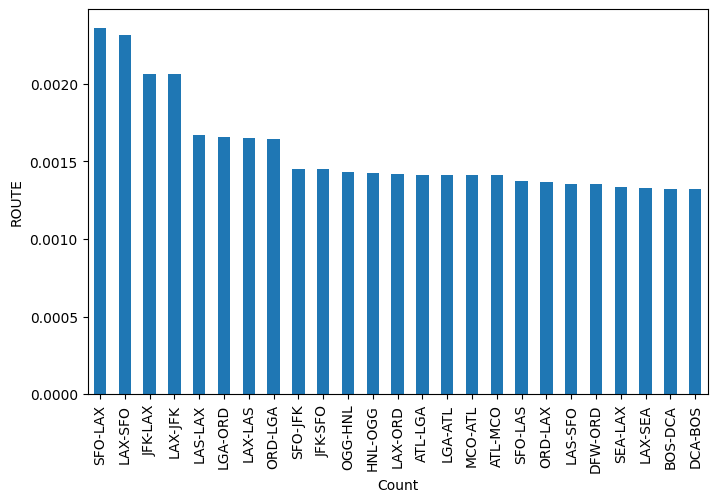

In [24]:
_ = topk_barplot(df_flights["ROUTE"], normalize=True, k=25, group_others=False)
plt.show()

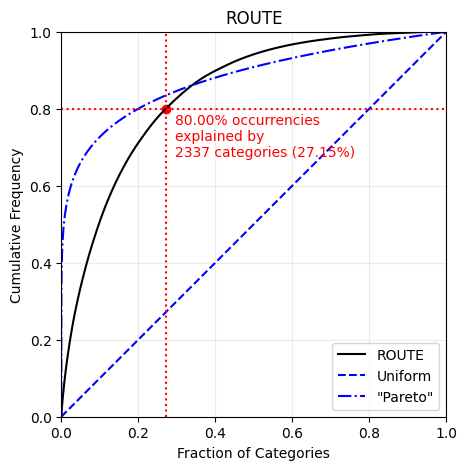

In [25]:
_ = cumsum_plot(df_flights["ROUTE"], annotate=True, threshold=0.8)
plt.show()

In [26]:
df_flights["AIRLINE"].value_counts(normalize=True)

AIRLINE
WN    0.216848
DL    0.150519
AA    0.124759
OO    0.101108
EV    0.098293
UA    0.088626
MQ    0.050632
B6    0.045892
US    0.034149
AS    0.029647
NK    0.020171
F9    0.015610
HA    0.013107
VX    0.010638
Name: proportion, dtype: float64

<Axes: xlabel='AIRLINE'>

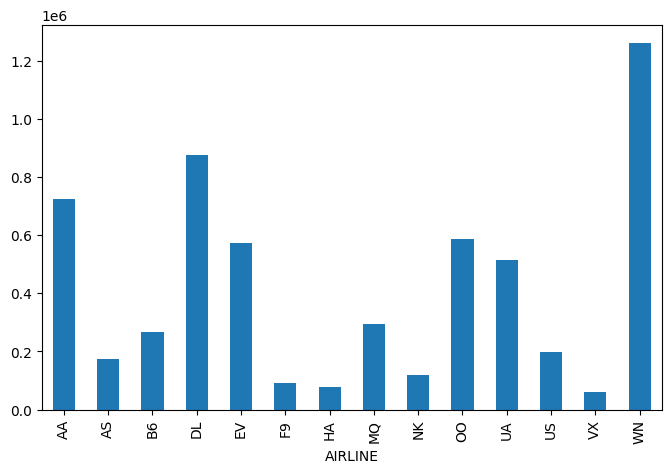

In [27]:
df_flights["AIRLINE"].value_counts().sort_index().plot(kind="bar", figsize=(8, 5))

In [28]:
df_flights["CANCELLED"].value_counts(normalize=True)

CANCELLED
0    0.984554
1    0.015446
Name: proportion, dtype: float64

In [29]:
df_flights[df_flights["CANCELLED"] == 1].info()

<class 'pandas.DataFrame'>
Index: 89884 entries, 32 to 5818843
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   YEAR                 89884 non-null  int64   
 1   MONTH                89884 non-null  int64   
 2   DAY                  89884 non-null  int64   
 3   DAY_OF_WEEK          89884 non-null  int64   
 4   AIRLINE              89884 non-null  str     
 5   FLIGHT_NUMBER        89884 non-null  int64   
 6   TAIL_NUMBER          75163 non-null  str     
 7   ORIGIN_AIRPORT       89884 non-null  object  
 8   DESTINATION_AIRPORT  89884 non-null  object  
 9   SCHEDULED_DEPARTURE  89884 non-null  int64   
 10  DEPARTURE_TIME       3731 non-null   float64 
 11  DEPARTURE_DELAY      3731 non-null   float64 
 12  TAXI_OUT             837 non-null    float64 
 13  WHEELS_OFF           837 non-null    float64 
 14  SCHEDULED_TIME       89879 non-null  float64 
 15  ELAPSED_TIME         0 non-null 

In [30]:
df_flights[df_flights["CANCELLED"] == 1].sample(n=sample_size)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,YEAR-MONTH,DAY_OF_WEEK_ABBR,HOUR,MINUTE,ROUTE
476243,2015,2,1,7,UA,1412,NaN,ORD,PHL,1310,NaN,NaN,NaN,NaN,133.0,NaN,NaN,678,NaN,NaN,1623,NaN,NaN,0,1,B,NaN,NaN,NaN,NaN,NaN,201502,SUN,13,10,ORD-PHL
1720354,2015,4,20,1,WN,4575,N7740A,ISP,MCO,1610,NaN,NaN,NaN,NaN,165.0,NaN,NaN,971,NaN,NaN,1855,NaN,NaN,0,1,B,NaN,NaN,NaN,NaN,NaN,201504,MON,16,10,ISP-MCO
3367825,2015,7,29,3,HA,42,NaN,OGG,SFO,1435,NaN,NaN,NaN,NaN,295.0,NaN,NaN,2338,NaN,NaN,2230,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN,201507,WED,14,35,OGG-SFO
842965,2015,2,25,3,MQ,3626,N614MQ,DFW,CVG,1100,NaN,NaN,NaN,NaN,128.0,NaN,NaN,812,NaN,NaN,1408,NaN,NaN,0,1,B,NaN,NaN,NaN,NaN,NaN,201502,WED,11,0,DFW-CVG
963752,2015,3,5,4,UA,1741,NaN,BWI,SFO,605,NaN,NaN,NaN,NaN,380.0,NaN,NaN,2457,NaN,NaN,925,NaN,NaN,0,1,B,NaN,NaN,NaN,NaN,NaN,201503,THU,6,5,BWI-SFO
4805835,2015,10,27,2,WN,2609,N626SW,14771,12892,1500,NaN,NaN,NaN,NaN,85.0,NaN,NaN,337,NaN,NaN,1625,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN,201510,TUE,15,0,14771-12892
1715084,2015,4,20,1,MQ,3407,N6EAMQ,CMH,LGA,1055,NaN,NaN,NaN,NaN,97.0,NaN,NaN,479,NaN,NaN,1232,NaN,NaN,0,1,C,NaN,NaN,NaN,NaN,NaN,201504,MON,10,55,CMH-LGA
397568,2015,1,27,2,US,1728,NaN,PHL,MCO,800,NaN,NaN,NaN,NaN,172.0,NaN,NaN,861,NaN,NaN,1052,NaN,NaN,0,1,B,NaN,NaN,NaN,NaN,NaN,201501,TUE,8,0,PHL-MCO
393236,2015,1,26,1,OO,5379,N567SW,LAX,CLD,1922,NaN,NaN,NaN,NaN,46.0,NaN,NaN,86,NaN,NaN,2008,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN,201501,MON,19,22,LAX-CLD
2632144,2015,6,15,1,OO,5594,N943SW,GRB,ORD,1728,NaN,NaN,NaN,NaN,57.0,NaN,NaN,173,NaN,NaN,1825,NaN,NaN,0,1,B,NaN,NaN,NaN,NaN,NaN,201506,MON,17,28,GRB-ORD


In [31]:
df_flights["DIVERTED"].value_counts(normalize=True)

DIVERTED
0    0.99739
1    0.00261
Name: proportion, dtype: float64

In [32]:
df_flights[df_flights["DIVERTED"] == 1].info()

<class 'pandas.DataFrame'>
Index: 15187 entries, 724 to 5818160
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   YEAR                 15187 non-null  int64   
 1   MONTH                15187 non-null  int64   
 2   DAY                  15187 non-null  int64   
 3   DAY_OF_WEEK          15187 non-null  int64   
 4   AIRLINE              15187 non-null  str     
 5   FLIGHT_NUMBER        15187 non-null  int64   
 6   TAIL_NUMBER          15187 non-null  str     
 7   ORIGIN_AIRPORT       15187 non-null  object  
 8   DESTINATION_AIRPORT  15187 non-null  object  
 9   SCHEDULED_DEPARTURE  15187 non-null  int64   
 10  DEPARTURE_TIME       15187 non-null  float64 
 11  DEPARTURE_DELAY      15187 non-null  float64 
 12  TAXI_OUT             15187 non-null  float64 
 13  WHEELS_OFF           15187 non-null  float64 
 14  SCHEDULED_TIME       15186 non-null  float64 
 15  ELAPSED_TIME         0 non-null

In [33]:
df_flights[df_flights["DIVERTED"] == 1].sample(n=sample_size)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,YEAR-MONTH,DAY_OF_WEEK_ABBR,HOUR,MINUTE,ROUTE
2654503,2015,6,17,3,AA,1264,N3GWAA,BNA,DFW,600,559.0,-1.0,21.0,620.0,117.0,NaN,NaN,631,1438.0,12.0,757,1450.0,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN,201506,WED,6,0,BNA-DFW
1652785,2015,4,16,4,UA,790,N415UA,SFO,IAH,1145,1143.0,-2.0,18.0,1201.0,235.0,NaN,NaN,1635,112.0,18.0,1740,130.0,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN,201504,THU,11,45,SFO-IAH
305968,2015,1,21,3,AS,805,N563AS,SEA,SMF,650,638.0,-12.0,62.0,740.0,108.0,NaN,NaN,605,1126.0,6.0,838,1132.0,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN,201501,WED,6,50,SEA-SMF
2448393,2015,6,4,4,US,1748,N204UW,MCO,PHL,1708,1758.0,50.0,12.0,1810.0,161.0,NaN,NaN,861,2254.0,6.0,1949,2300.0,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN,201506,THU,17,8,MCO-PHL
4927290,2015,11,4,3,UA,449,N33292,ORD,SAN,1228,1232.0,4.0,25.0,1257.0,272.0,NaN,NaN,1723,1810.0,14.0,1500,1824.0,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN,201511,WED,12,28,ORD-SAN
2703923,2015,6,19,5,OO,4737,N461SW,MSP,DIK,1953,1949.0,-4.0,25.0,2014.0,111.0,NaN,NaN,481,2205.0,4.0,2044,2209.0,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN,201506,FRI,19,53,MSP-DIK
3115916,2015,7,14,2,DL,1877,N981DL,ORD,ATL,1655,1741.0,46.0,30.0,1811.0,129.0,NaN,NaN,606,45.0,4.0,2004,49.0,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN,201507,TUE,16,55,ORD-ATL
867195,2015,2,26,4,WN,4637,N8642E,STL,DEN,1855,1900.0,5.0,10.0,1910.0,145.0,NaN,NaN,770,2244.0,25.0,2020,2309.0,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN,201502,THU,18,55,STL-DEN
5309032,2015,11,29,7,EV,2802,N907EV,DFW,LRD,845,847.0,2.0,26.0,913.0,87.0,NaN,NaN,396,1725.0,6.0,1012,1731.0,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN,201511,SUN,8,45,DFW-LRD
3008074,2015,7,8,3,AA,2312,N4YBAA,ORD,DFW,1020,1018.0,-2.0,16.0,1034.0,152.0,NaN,NaN,802,1516.0,14.0,1252,1530.0,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN,201507,WED,10,20,ORD-DFW


In [34]:
df_flights_discarded = df_flights[(df_flights["CANCELLED"] == 1) | (df_flights["DIVERTED"] == 1)]

In [35]:
df_flights_discarded.info()

<class 'pandas.DataFrame'>
Index: 105071 entries, 32 to 5818843
Data columns (total 36 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   YEAR                 105071 non-null  int64   
 1   MONTH                105071 non-null  int64   
 2   DAY                  105071 non-null  int64   
 3   DAY_OF_WEEK          105071 non-null  int64   
 4   AIRLINE              105071 non-null  str     
 5   FLIGHT_NUMBER        105071 non-null  int64   
 6   TAIL_NUMBER          90350 non-null   str     
 7   ORIGIN_AIRPORT       105071 non-null  object  
 8   DESTINATION_AIRPORT  105071 non-null  object  
 9   SCHEDULED_DEPARTURE  105071 non-null  int64   
 10  DEPARTURE_TIME       18918 non-null   float64 
 11  DEPARTURE_DELAY      18918 non-null   float64 
 12  TAXI_OUT             16024 non-null   float64 
 13  WHEELS_OFF           16024 non-null   float64 
 14  SCHEDULED_TIME       105065 non-null  float64 
 15  ELAPSED_TIME  

In [36]:
df_flights_discarded.sample(n=sample_size)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,YEAR-MONTH,DAY_OF_WEEK_ABBR,HOUR,MINUTE,ROUTE
5764062,2015,12,28,1,MQ,3166,N691MQ,DFW,COU,1205,NaN,NaN,NaN,NaN,98.0,NaN,NaN,489,NaN,NaN,1343,NaN,NaN,0,1,B,NaN,NaN,NaN,NaN,NaN,201512,MON,12,5,DFW-COU
963120,2015,3,5,4,AA,328,N3JNAA,DEN,DFW,523,NaN,NaN,NaN,NaN,116.0,NaN,NaN,641,NaN,NaN,819,NaN,NaN,0,1,B,NaN,NaN,NaN,NaN,NaN,201503,THU,5,23,DEN-DFW
590196,2015,2,9,1,B6,1039,N368JB,BOS,AUS,638,NaN,NaN,NaN,NaN,295.0,NaN,NaN,1698,NaN,NaN,1033,NaN,NaN,0,1,B,NaN,NaN,NaN,NaN,NaN,201502,MON,6,38,BOS-AUS
5319279,2015,11,29,7,OO,4573,N607SK,BOI,SEA,1851,1850.0,-1.0,16.0,1906.0,90.0,NaN,NaN,399,NaN,NaN,1921,NaN,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN,201511,SUN,18,51,BOI-SEA
4076258,2015,9,11,5,AA,1078,N3FXAA,MIA,EWR,715,NaN,NaN,NaN,NaN,175.0,NaN,NaN,1085,NaN,NaN,1010,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN,201509,FRI,7,15,MIA-EWR
1176041,2015,3,18,3,EV,5182,N741EV,CLE,DTW,650,649.0,-1.0,17.0,706.0,58.0,NaN,NaN,95,1213.0,6.0,748,1219.0,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN,201503,WED,6,50,CLE-DTW
3390825,2015,7,30,4,UA,705,NaN,PBI,EWR,2005,NaN,NaN,NaN,NaN,173.0,NaN,NaN,1023,NaN,NaN,2258,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN,201507,THU,20,5,PBI-EWR
786665,2015,2,21,6,VX,413,N842VA,JFK,LAX,1655,NaN,NaN,NaN,NaN,390.0,NaN,NaN,2475,NaN,NaN,2025,NaN,NaN,0,1,C,NaN,NaN,NaN,NaN,NaN,201502,SAT,16,55,JFK-LAX
2968199,2015,7,6,1,WN,559,N907WN,MSP,MDW,530,NaN,NaN,NaN,NaN,85.0,NaN,NaN,349,NaN,NaN,655,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN,201507,MON,5,30,MSP-MDW
1333052,2015,3,27,5,B6,813,N789JB,HPN,FLL,1529,1523.0,-6.0,11.0,1534.0,184.0,NaN,NaN,1097,2128.0,21.0,1833,2149.0,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN,201503,FRI,15,29,HPN-FLL


In [37]:
df_flights_discarded["YEAR-MONTH"].value_counts(normalize=True)

YEAR-MONTH
201502    0.204890
201501    0.123298
201503    0.115865
201506    0.105167
201512    0.090539
201505    0.069972
201508    0.062624
201507    0.060283
201504    0.056153
201511    0.053345
201510    0.031284
201509    0.026582
Name: proportion, dtype: float64

<Axes: xlabel='YEAR-MONTH'>

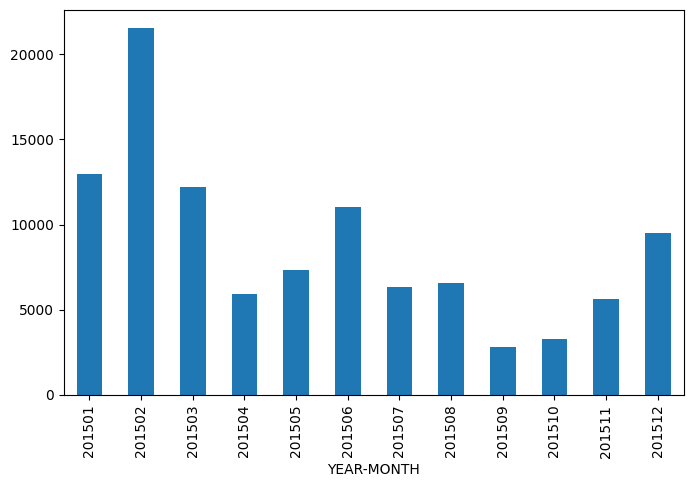

In [38]:
df_flights_discarded["YEAR-MONTH"].value_counts().sort_index().plot(kind="bar", figsize=(8, 5))

In [39]:
df_flights_discarded["DAY"].value_counts(normalize=True)

DAY
27    0.062482
1     0.056181
2     0.052079
28    0.050927
5     0.047121
15    0.045341
26    0.043808
9     0.043447
23    0.041372
21    0.034424
17    0.033968
20    0.032873
16    0.032673
8     0.032492
10    0.032292
3     0.029789
18    0.029228
4     0.029123
25    0.028952
24    0.027800
22    0.026515
11    0.022994
14    0.022128
6     0.021919
30    0.019625
13    0.017664
7     0.017493
29    0.016969
12    0.016950
19    0.016817
31    0.014552
Name: proportion, dtype: float64

<Axes: xlabel='DAY'>

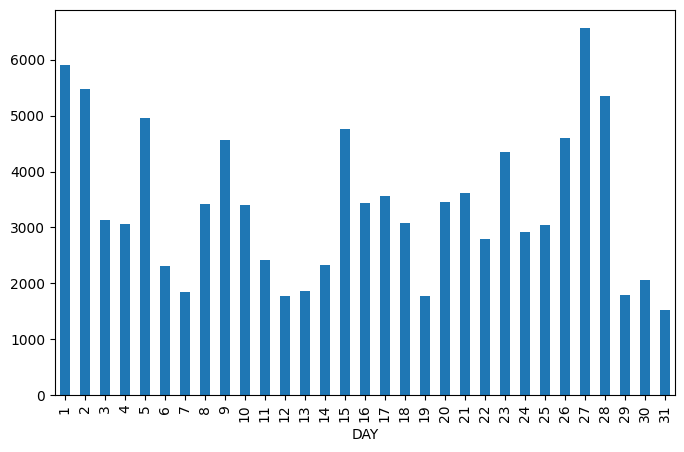

In [40]:
df_flights_discarded["DAY"].value_counts().sort_index().plot(kind="bar", figsize=(8, 5))

In [41]:
df_flights_discarded["DAY_OF_WEEK_ABBR"].value_counts(normalize=True)

DAY_OF_WEEK_ABBR
MON    0.226028
TUE    0.163708
SUN    0.144750
THU    0.139287
WED    0.120442
FRI    0.102997
SAT    0.102788
Name: proportion, dtype: float64

<Axes: xlabel='DAY_OF_WEEK_ABBR'>

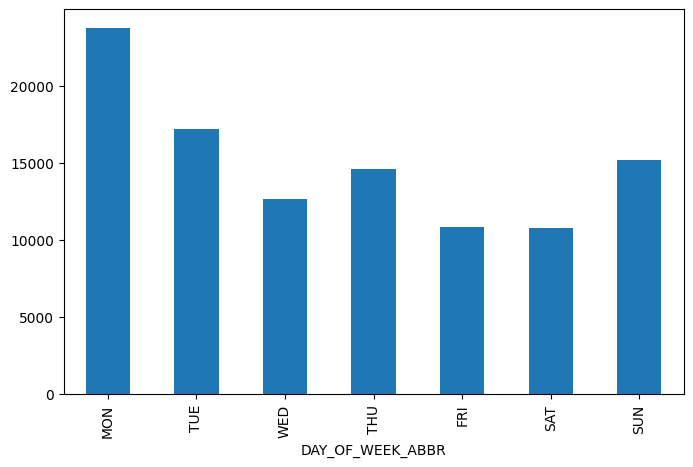

In [42]:
df_flights_discarded["DAY_OF_WEEK_ABBR"].value_counts().sort_index().plot(kind="bar", figsize=(8, 5))

In [43]:
df_flights_discarded["HOUR"].value_counts(normalize=True)

HOUR
6     0.080250
17    0.074340
18    0.070267
19    0.065860
16    0.064119
15    0.061520
7     0.059274
8     0.058874
14    0.056438
20    0.055391
12    0.054668
13    0.054573
10    0.053640
11    0.052184
9     0.048577
21    0.038650
5     0.022880
22    0.020872
23    0.005006
0     0.001523
1     0.000647
2     0.000295
3     0.000105
4     0.000048
Name: proportion, dtype: float64

<Axes: xlabel='HOUR'>

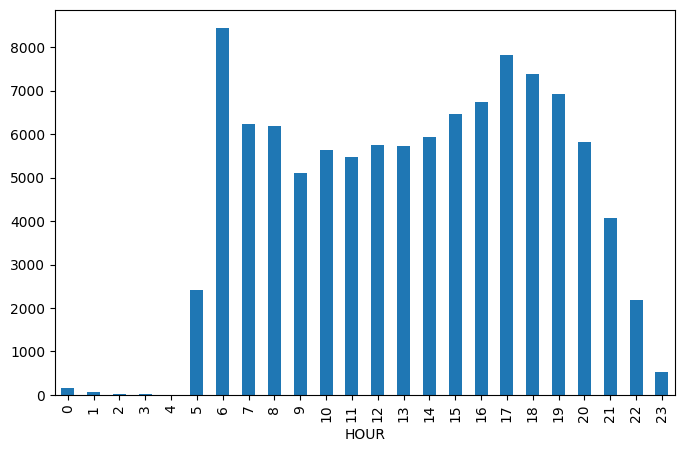

In [44]:
df_flights_discarded["HOUR"].value_counts().sort_index().plot(kind="bar", figsize=(8, 5))

In [45]:
df_flights_discarded["ORIGIN_AIRPORT"].value_counts(normalize=True)

ORIGIN_AIRPORT
ORD      0.088797
DFW      0.065708
LGA      0.045407
EWR      0.032654
ATL      0.031693
           ...   
14986    0.000010
13933    0.000010
14685    0.000010
14843    0.000010
11042    0.000010
Name: proportion, Length: 653, dtype: float64

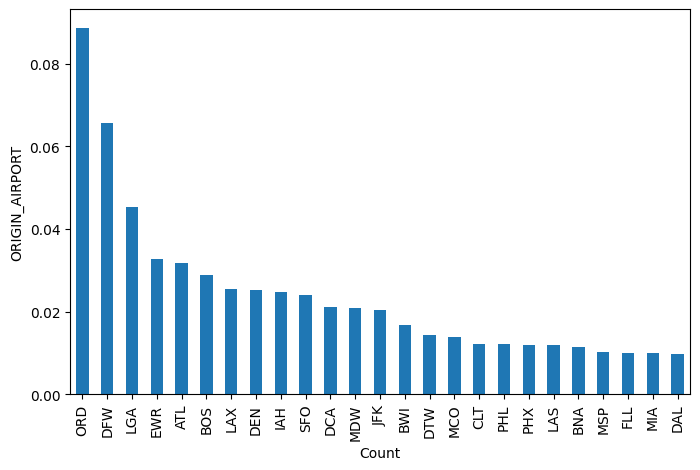

In [46]:
_ = topk_barplot(df_flights_discarded["ORIGIN_AIRPORT"], normalize=True, k=25, group_others=False)
plt.show()

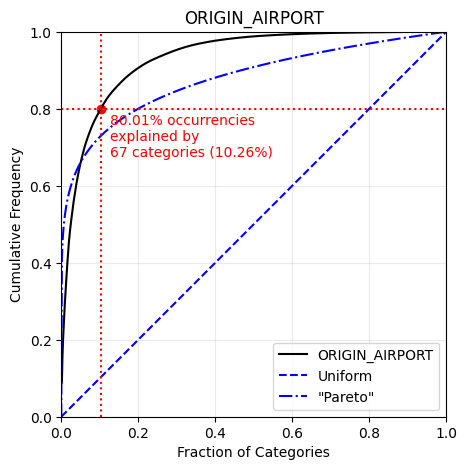

In [47]:
_ = cumsum_plot(df_flights_discarded["ORIGIN_AIRPORT"], annotate=True, threshold=0.8)
plt.show()

In [48]:
df_flights_discarded["DESTINATION_AIRPORT"].value_counts(normalize=True)

DESTINATION_AIRPORT
ORD      0.095573
DFW      0.074407
LGA      0.048101
ATL      0.036433
EWR      0.034329
           ...   
12448    0.000010
14696    0.000010
11433    0.000010
11042    0.000010
LWS      0.000010
Name: proportion, Length: 636, dtype: float64

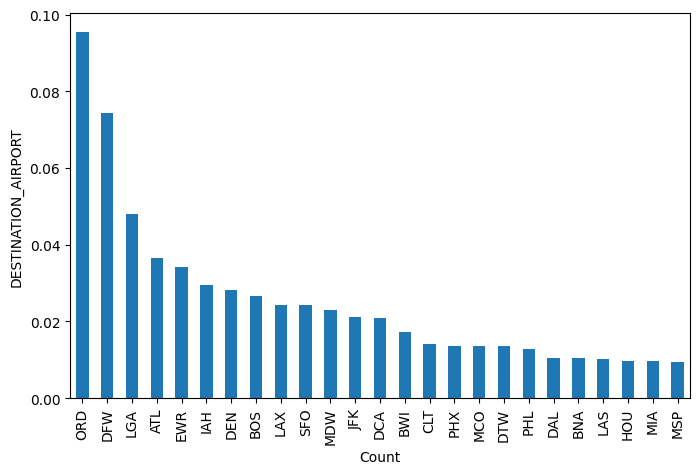

In [49]:
_ = topk_barplot(df_flights_discarded["DESTINATION_AIRPORT"], normalize=True, k=25, group_others=False)
plt.show()

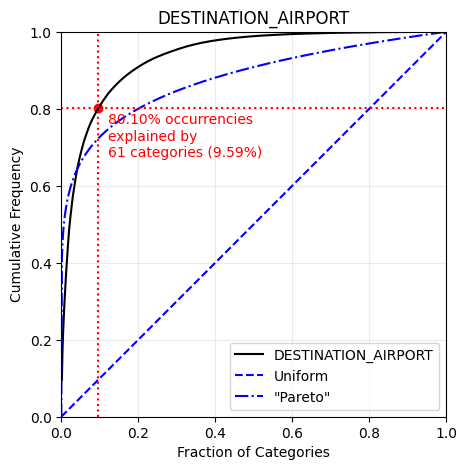

In [50]:
_ = cumsum_plot(df_flights_discarded["DESTINATION_AIRPORT"], annotate=True, threshold=0.8)
plt.show()

In [51]:
df_flights_discarded["ROUTE"].value_counts(normalize=True)

ROUTE
ORD-LGA    0.004511
LGA-ORD    0.004378
BOS-LGA    0.004283
LGA-BOS    0.004207
LAX-SFO    0.003312
             ...   
IAD-SJU    0.000010
IAD-JAC    0.000010
IAD-SAT    0.000010
RSW-DEN    0.000010
LRD-HRL    0.000010
Name: proportion, Length: 5544, dtype: float64

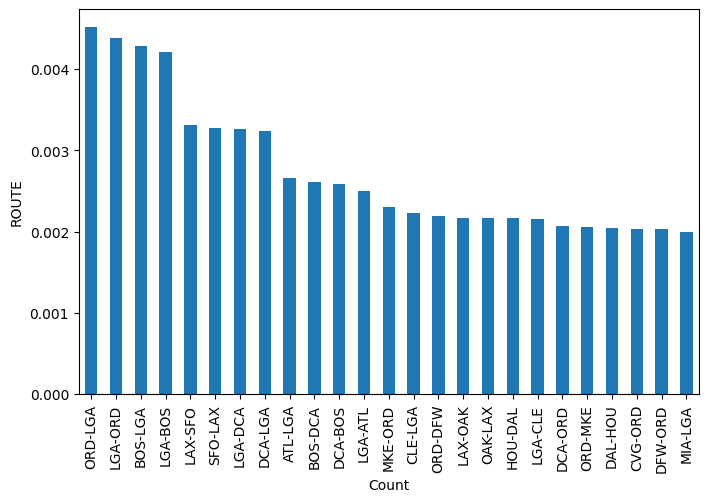

In [52]:
_ = topk_barplot(df_flights_discarded["ROUTE"], normalize=True, k=25, group_others=False)
plt.show()

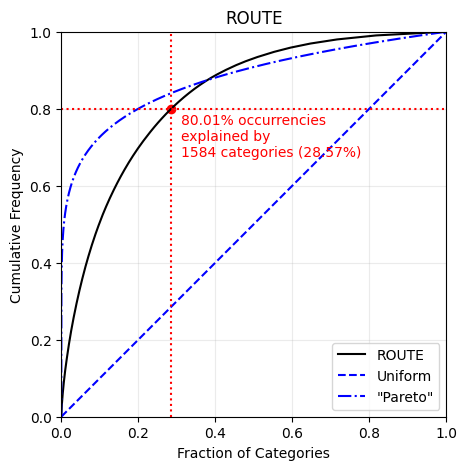

In [53]:
_ = cumsum_plot(df_flights_discarded["ROUTE"], annotate=True, threshold=0.8)
plt.show()

In [54]:
df_flights_discarded["AIRLINE"].value_counts(normalize=True)

AIRLINE
WN    0.185132
EV    0.163937
MQ    0.150765
AA    0.124192
OO    0.109821
UA    0.075768
DL    0.053354
B6    0.047644
US    0.042752
NK    0.020805
AS    0.010298
F9    0.007100
VX    0.006234
HA    0.002199
Name: proportion, dtype: float64

<Axes: xlabel='AIRLINE'>

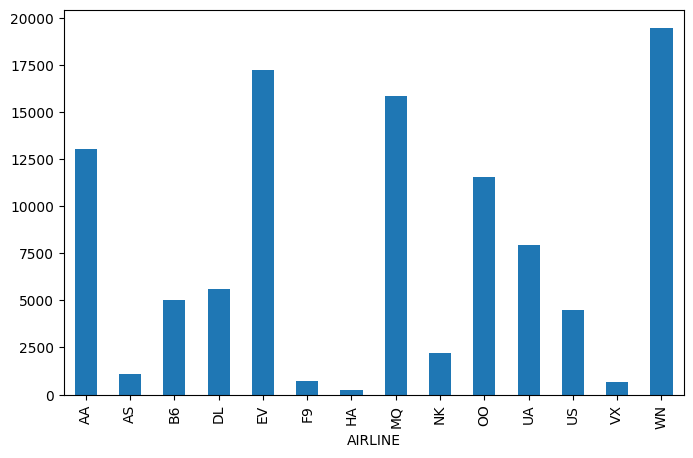

In [55]:
df_flights_discarded["AIRLINE"].value_counts().sort_index().plot(kind="bar", figsize=(8, 5))

In [56]:
(df_flights_discarded["YEAR-MONTH"].value_counts() / df_flights["YEAR-MONTH"].value_counts()).sort_values(ascending=False)

YEAR-MONTH
201502    0.050159
201501    0.027566
201503    0.024140
201506    0.021929
201512    0.019851
201505    0.014793
201508    0.012888
201507    0.012164
201504    0.012161
201511    0.011977
201510    0.006761
201509    0.006007
Name: count, dtype: float64

In [57]:
(df_flights_discarded["DAY"].value_counts() / df_flights["DAY"].value_counts()).sort_values(ascending=False)

DAY
27    0.034207
1     0.031154
28    0.027957
2     0.027920
5     0.026090
15    0.024690
26    0.024564
9     0.023504
23    0.022458
21    0.019096
17    0.018655
10    0.017925
20    0.017649
8     0.017601
16    0.017524
3     0.016473
25    0.016240
18    0.016046
4     0.016030
24    0.015788
31    0.014729
22    0.014456
11    0.012665
14    0.012327
6     0.012043
30    0.011534
29    0.009936
7     0.009798
13    0.009514
12    0.009331
19    0.009142
Name: count, dtype: float64

In [58]:
(df_flights_discarded["DAY_OF_WEEK_ABBR"].value_counts() / df_flights["DAY_OF_WEEK_ABBR"].value_counts()).sort_values(ascending=False)

DAY_OF_WEEK_ABBR
MON    0.027438
TUE    0.020366
SUN    0.018598
THU    0.016773
SAT    0.015417
WED    0.014786
FRI    0.012551
Name: count, dtype: float64

In [59]:
(df_flights_discarded["HOUR"].value_counts() / df_flights["HOUR"].value_counts()).sort_values(ascending=False)

HOUR
20    0.022434
18    0.022080
2     0.021924
21    0.021662
19    0.020885
6     0.020720
5     0.020364
16    0.020161
17    0.020010
22    0.018656
14    0.017985
15    0.017577
8     0.016236
12    0.016152
7     0.015809
13    0.015774
11    0.015312
10    0.015165
9     0.014525
3     0.014139
1     0.013181
23    0.011908
0     0.010911
4     0.009416
Name: count, dtype: float64

In [60]:
(df_flights_discarded["ORIGIN_AIRPORT"].value_counts() / df_flights["ORIGIN_AIRPORT"].value_counts()).sort_values(ascending=False)

ORIGIN_AIRPORT
13964    1.000000
10423    0.509174
11905    0.500000
11097    0.500000
10747    0.500000
           ...   
AKN           NaN
DLG           NaN
LWS           NaN
MVY           NaN
WYS           NaN
Name: count, Length: 930, dtype: float64

In [61]:
(df_flights_discarded["DESTINATION_AIRPORT"].value_counts() / df_flights["DESTINATION_AIRPORT"].value_counts()).sort_values(ascending=False)

DESTINATION_AIRPORT
13964    1.000000
11097    0.500000
10423    0.437788
10747    0.363636
12206    0.312500
           ...   
16218         NaN
AKN           NaN
DLG           NaN
MVY           NaN
PPG           NaN
Name: count, Length: 930, dtype: float64

In [62]:
(df_flights_discarded["ROUTE"].value_counts() / df_flights["ROUTE"].value_counts()).sort_values(ascending=False)

ROUTE
TYS-LEX        1.0
PLN-CIU        1.0
PHX-MHT        1.0
12892-14908    1.0
CLE-SCE        1.0
              ... 
TVC-MSP        NaN
TYS-DTW        NaN
UST-IAD        NaN
WYS-SLC        NaN
XNA-SLC        NaN
Name: count, Length: 8609, dtype: float64

In [63]:
(df_flights_discarded["AIRLINE"].value_counts() / df_flights["AIRLINE"].value_counts()).sort_values(ascending=False)

AIRLINE
MQ    0.053765
EV    0.030115
US    0.022605
OO    0.019612
B6    0.018746
NK    0.018623
AA    0.017974
UA    0.015437
WN    0.015415
VX    0.010581
F9    0.008213
DL    0.006400
AS    0.006272
HA    0.003029
Name: count, dtype: float64

In [64]:
airports_csv = "airports.csv"
df_airports = pd.read_csv(os.path.join(current_dir, data_dir, airports_csv))

In [65]:
df_airports.info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   IATA_CODE  322 non-null    str    
 1   AIRPORT    322 non-null    str    
 2   CITY       322 non-null    str    
 3   STATE      322 non-null    str    
 4   COUNTRY    322 non-null    str    
 5   LATITUDE   319 non-null    float64
 6   LONGITUDE  319 non-null    float64
dtypes: float64(2), str(5)
memory usage: 17.7 KB


In [66]:
df_airports.sample(n=sample_size)

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
247,PSC,Tri-Cities Airport,Pasco,WA,USA,46.26468,-119.11903
267,SAF,Santa Fe Municipal Airport,Santa Fe,NM,USA,35.61678,-106.08814
163,JAC,Jackson Hole Airport,Jackson,WY,USA,43.60732,-110.73774
55,CDC,Cedar City Regional Airport,Cedar City,UT,USA,37.70097,-113.09858
271,SBA,Santa Barbara Municipal Airport (Santa Barbara...,Santa Barbara,CA,USA,34.42621,-119.84037
225,OMA,Eppley Airfield,Omaha,NE,USA,41.30252,-95.89417
288,SMX,Santa Maria Public Airport (Capt G. Allan Hanc...,Santa Maria,CA,USA,34.89925,-120.45758
94,DVL,Devils Lake Regional Airport,Devils Lake,ND,USA,48.11425,-98.90878
128,GRI,Central Nebraska Regional Airport,Grand Island,NE,USA,40.96747,-98.30861
231,OTH,Southwest Oregon Regional Airport (North Bend ...,North Bend,OR,USA,43.41714,-124.24603


In [67]:
df_airports["IC_ISNUM"] = df_airports["IATA_CODE"].apply(lambda x: x.isnumeric())
df_airports["IC_ISNUM"].value_counts(normalize=True)

IC_ISNUM
False    1.0
Name: proportion, dtype: float64

In [68]:
df_flights["OA_ISNUM"] = df_flights["ORIGIN_AIRPORT"].apply(lambda x: str(x).isnumeric())
df_flights["OA_ISNUM"].value_counts(normalize=True)

OA_ISNUM
False    0.916453
True     0.083547
Name: proportion, dtype: float64

In [69]:
df_flights["DA_ISNUM"] = df_flights["DESTINATION_AIRPORT"].apply(lambda x: str(x).isnumeric())
df_flights["DA_ISNUM"].value_counts(normalize=True)

DA_ISNUM
False    0.916453
True     0.083547
Name: proportion, dtype: float64

In [70]:
df_flights[df_flights["OA_ISNUM"] ^ df_flights["DA_ISNUM"]].info()

<class 'pandas.DataFrame'>
RangeIndex: 0 entries
Data columns (total 38 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   YEAR                 0 non-null      int64   
 1   MONTH                0 non-null      int64   
 2   DAY                  0 non-null      int64   
 3   DAY_OF_WEEK          0 non-null      int64   
 4   AIRLINE              0 non-null      str     
 5   FLIGHT_NUMBER        0 non-null      int64   
 6   TAIL_NUMBER          0 non-null      str     
 7   ORIGIN_AIRPORT       0 non-null      object  
 8   DESTINATION_AIRPORT  0 non-null      object  
 9   SCHEDULED_DEPARTURE  0 non-null      int64   
 10  DEPARTURE_TIME       0 non-null      float64 
 11  DEPARTURE_DELAY      0 non-null      float64 
 12  TAXI_OUT             0 non-null      float64 
 13  WHEELS_OFF           0 non-null      float64 
 14  SCHEDULED_TIME       0 non-null      float64 
 15  ELAPSED_TIME         0 non-null      float64 


In [71]:
df_flights_airport_isnum = df_flights[df_flights["OA_ISNUM"] | df_flights["DA_ISNUM"]]

In [72]:
df_flights_airport_isnum.info()

<class 'pandas.DataFrame'>
RangeIndex: 486165 entries, 4385712 to 4871876
Data columns (total 38 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   YEAR                 486165 non-null  int64   
 1   MONTH                486165 non-null  int64   
 2   DAY                  486165 non-null  int64   
 3   DAY_OF_WEEK          486165 non-null  int64   
 4   AIRLINE              486165 non-null  str     
 5   FLIGHT_NUMBER        486165 non-null  int64   
 6   TAIL_NUMBER          485811 non-null  str     
 7   ORIGIN_AIRPORT       486165 non-null  object  
 8   DESTINATION_AIRPORT  486165 non-null  object  
 9   SCHEDULED_DEPARTURE  486165 non-null  int64   
 10  DEPARTURE_TIME       483826 non-null  float64 
 11  DEPARTURE_DELAY      483826 non-null  float64 
 12  TAXI_OUT             483730 non-null  float64 
 13  WHEELS_OFF           483730 non-null  float64 
 14  SCHEDULED_TIME       486165 non-null  float64 
 15  ELAP

In [73]:
df_flights_airport_isnum.sample(n=sample_size)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,YEAR-MONTH,DAY_OF_WEEK_ABBR,HOUR,MINUTE,ROUTE,OA_ISNUM,DA_ISNUM
4451241,2015,10,5,1,VX,340,N837VA,14771,11697,900,856.0,-4.0,10.0,906.0,320.0,319.0,302.0,2584,1708.0,7.0,1720,1715.0,-5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,201510,MON,9,0,14771-11697,True,True
4869654,2015,10,31,6,AS,40,N779AS,10170,10299,1715,1708.0,-7.0,19.0,1727.0,48.0,67.0,45.0,253,1812.0,3.0,1803,1815.0,12.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,201510,SAT,17,15,10170-10299,True,True
4517975,2015,10,9,5,EV,4879,N858AS,11433,10434,1000,1000.0,0.0,13.0,1013.0,82.0,76.0,60.0,399,1113.0,3.0,1122,1116.0,-6.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,201510,FRI,10,0,11433-10434,True,True
4469895,2015,10,6,2,WN,248,N670SW,12889,12896,1110,1123.0,13.0,14.0,1137.0,120.0,119.0,102.0,775,1519.0,3.0,1510,1522.0,12.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,201510,TUE,11,10,12889-12896,True,True
4776811,2015,10,25,7,EV,4759,N13988,11618,11278,1829,1823.0,-6.0,37.0,1900.0,77.0,88.0,46.0,199,1946.0,5.0,1946,1951.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,201510,SUN,18,29,11618-11278,True,True
4750495,2015,10,23,5,OO,6464,N941SW,13930,14696,2052,2051.0,-1.0,26.0,2117.0,48.0,55.0,17.0,84,2234.0,12.0,2240,2246.0,6.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,201510,FRI,20,52,13930-14696,True,True
4765507,2015,10,25,7,B6,2702,N328JB,12478,10792,659,656.0,-3.0,19.0,715.0,91.0,79.0,58.0,301,813.0,2.0,830,815.0,-15.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,201510,SUN,6,59,12478-10792,True,True
4393009,2015,10,1,4,DL,2276,N974DL,14321,10397,1221,1220.0,-1.0,10.0,1230.0,183.0,182.0,162.0,1027,1512.0,10.0,1524,1522.0,-2.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,201510,THU,12,21,14321-10397,True,True
4701749,2015,10,20,2,AA,1277,N3FDAA,11057,13303,2230,2227.0,-3.0,15.0,2242.0,121.0,104.0,85.0,650,7.0,4.0,31,11.0,-20.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,201510,TUE,22,30,11057-13303,True,True
4387346,2015,10,1,4,WN,2656,N480WN,14771,14908,700,655.0,-5.0,13.0,708.0,85.0,84.0,66.0,372,814.0,5.0,825,819.0,-6.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,201510,THU,7,0,14771-14908,True,True


In [74]:
df_flights_airport_isnum["YEAR-MONTH"].value_counts(normalize=True)

YEAR-MONTH
201510    1.0
Name: proportion, dtype: float64

In [75]:
df_flights_october = df_flights[df_flights["MONTH"] == 10]

In [76]:
df_flights_october.info()

<class 'pandas.DataFrame'>
RangeIndex: 486165 entries, 4385712 to 4871876
Data columns (total 38 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   YEAR                 486165 non-null  int64   
 1   MONTH                486165 non-null  int64   
 2   DAY                  486165 non-null  int64   
 3   DAY_OF_WEEK          486165 non-null  int64   
 4   AIRLINE              486165 non-null  str     
 5   FLIGHT_NUMBER        486165 non-null  int64   
 6   TAIL_NUMBER          485811 non-null  str     
 7   ORIGIN_AIRPORT       486165 non-null  object  
 8   DESTINATION_AIRPORT  486165 non-null  object  
 9   SCHEDULED_DEPARTURE  486165 non-null  int64   
 10  DEPARTURE_TIME       483826 non-null  float64 
 11  DEPARTURE_DELAY      483826 non-null  float64 
 12  TAXI_OUT             483730 non-null  float64 
 13  WHEELS_OFF           483730 non-null  float64 
 14  SCHEDULED_TIME       486165 non-null  float64 
 15  ELAP

In [77]:
df_flights_october.sample(n=sample_size)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,YEAR-MONTH,DAY_OF_WEEK_ABBR,HOUR,MINUTE,ROUTE,OA_ISNUM,DA_ISNUM
4654077,2015,10,18,7,WN,839,N570WN,14869,11259,615,610.0,-5.0,17.0,627.0,155.0,155.0,134.0,999,941.0,4.0,950,945.0,-5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,201510,SUN,6,15,14869-11259,True,True
4495562,2015,10,7,3,WN,60,N418WN,12191,11259,2100,2057.0,-3.0,6.0,2103.0,55.0,51.0,40.0,239,2143.0,5.0,2155,2148.0,-7.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,201510,WED,21,0,12191-11259,True,True
4423484,2015,10,3,6,OO,3449,N223AG,11638,14057,1035,1033.0,-2.0,10.0,1043.0,114.0,114.0,101.0,626,1224.0,3.0,1229,1227.0,-2.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,201510,SAT,10,35,11638-14057,True,True
4603352,2015,10,14,3,WN,490,N269WN,10397,12953,1730,1750.0,20.0,22.0,1812.0,140.0,122.0,97.0,762,1949.0,3.0,1950,1952.0,2.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,201510,WED,17,30,10397-12953,True,True
4445977,2015,10,4,7,EV,2707,N684JW,11298,14814,2020,2014.0,-6.0,24.0,2038.0,64.0,62.0,34.0,190,2112.0,4.0,2124,2116.0,-8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,201510,SUN,20,20,11298-14814,True,True
4530528,2015,10,10,6,WN,616,N565WN,14492,11259,625,623.0,-2.0,7.0,630.0,185.0,160.0,149.0,1052,759.0,4.0,830,803.0,-27.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,201510,SAT,6,25,14492-11259,True,True
4562208,2015,10,12,1,WN,1902,N355SW,14107,11292,900,855.0,-5.0,20.0,915.0,110.0,113.0,87.0,602,1142.0,6.0,1150,1148.0,-2.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,201510,MON,9,0,14107-11292,True,True
4858537,2015,10,30,5,AS,368,N474AS,14747,14893,1955,1948.0,-7.0,17.0,2005.0,103.0,98.0,77.0,605,2122.0,4.0,2138,2126.0,-12.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,201510,FRI,19,55,14747-14893,True,True
4500084,2015,10,8,4,HA,121,N479HA,12402,12173,846,846.0,0.0,9.0,855.0,50.0,58.0,39.0,216,934.0,10.0,936,944.0,8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,201510,THU,8,46,12402-12173,True,True
4764824,2015,10,25,7,UA,212,N502UA,14771,11618,600,600.0,0.0,24.0,624.0,322.0,315.0,280.0,2565,1404.0,11.0,1422,1415.0,-7.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,201510,SUN,6,0,14771-11618,True,True


In [78]:
df_flights_october["OA_ISNUM"].value_counts(normalize=True)

OA_ISNUM
True    1.0
Name: proportion, dtype: float64

In [79]:
df_flights_october["DA_ISNUM"].value_counts(normalize=True)

DA_ISNUM
True    1.0
Name: proportion, dtype: float64